In [3]:
#!/usr/bin/env python3
"""
=============================================================================
SCRIPT 2: NK + T CELL LINEAGES — DONOR-LEVEL VALIDATION
=============================================================================
NK claims to re-validate with full trajectory:
  1. NK proportion decline (already confirmed but need full trajectory stats)
  2. Per-cell cytotoxicity genes (GZMB, PRF1, GNLY, IFNG)
  3. NK subcluster shifts (NK_c02-KLRC2 loss)
  4. NK exhaustion/checkpoint markers

T cell claims to validate:
  1. CD8_T checkpoint/exhaustion (CD8T_c08-LAYN epicenter)
  2. CD4_T key functional genes
  3. Naive T / Memory T trajectory
  4. Key checkpoint genes (PD-1, LAG3, TIM3, TIGIT)
=============================================================================
"""
!pip install -q scanpy leidenalg pyscenic gseapy openpyxl

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import scipy.sparse as sp
import os
import warnings
warnings.filterwarnings('ignore')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.3/53.3 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 605.3/605.3 kB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 110.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━

In [4]:
# --- Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [27]:
# ============================================================
# SETUP
# ============================================================
DATA_PATH = '/content/drive/MyDrive/ITLAS/data/processed/GSE182159_gut2021_annotated.h5ad'
SAVE_DIR = '/content/drive/MyDrive/ITLAS/results/task3_donor_validation/figures'
os.makedirs(SAVE_DIR, exist_ok=True)

print("Loading dataset...")
adata = sc.read_h5ad(DATA_PATH)
print(f"Dataset: {adata.shape[0]} cells, {adata.shape[1]} genes")

STAGE_ORDER = ['NL', 'IT', 'IA', 'AR', 'CR']
STAGE_COLORS = {'NL': 'forestgreen', 'IT': 'crimson', 'IA': 'darkorange',
                'AR': 'royalblue', 'CR': 'purple'}
np.random.seed(42)

Loading dataset...
Dataset: 243000 cells, 24452 genes


In [28]:
# donor_id: GSM5519467_P190604_Blood_1 → P190604
CSV_DIR = '/content/drive/MyDrive/ITLAS/results/task3_donor_validation/csv'
os.makedirs(CSV_DIR, exist_ok=True)
adata.obs['donor_id'] = adata.obs['sample'].astype(str).apply(
    lambda x: x.split('_')[1] if len(x.split('_')) >= 2 else x)

# sample_id: globally unique
adata.obs['sample_id'] = adata.obs['Stage'].astype(str) + '_' + adata.obs['donor_id'].astype(str)

STAGE_ORDER = ['NL', 'IT', 'IA', 'AR', 'CR']
LINEAGES = ['NK', 'CD8_T', 'CD4_T', 'Myeloid', 'B', 'PlasmaB']

# Quick check
print(f"Donors: {adata.obs['donor_id'].nunique()}")
for s in STAGE_ORDER:
    n = adata.obs[adata.obs['Stage']==s]['sample_id'].nunique()
    print(f"  {s}: n={n} sample_ids")

Donors: 23
  NL: n=6 sample_ids
  IT: n=6 sample_ids
  IA: n=5 sample_ids
  AR: n=3 sample_ids
  CR: n=3 sample_ids


In [41]:
# ============================================================
# HELPER FUNCTIONS (same as Script 1)
# ============================================================
def get_donor_means(adata_sub, gene_name):
    if gene_name not in adata_sub.var_names:
        return None
    if sp.issparse(adata_sub.X):
        expr = adata_sub[:, gene_name].X.toarray().flatten()
    else:
        expr = adata_sub[:, gene_name].X.flatten()
    df = pd.DataFrame({
        'expression': expr,
        'Stage': adata_sub.obs['Stage'].astype(str).values,
        'donor_id': adata_sub.obs['donor_id'].astype(str).values
    })
    return df.groupby(['donor_id', 'Stage'])['expression'].mean().reset_index()

def donor_test(vals_a, vals_b):
    """Direct array input — no DataFrame filtering."""
    if len(vals_a) < 2 or len(vals_b) < 2:
        return {'n_a':len(vals_a),'n_b':len(vals_b),'change':'N/A',
                'consist':0,'total':0,'p':1.0}
    _, p_gt = mannwhitneyu(vals_a, vals_b, alternative='greater')
    _, p_lt = mannwhitneyu(vals_a, vals_b, alternative='less')
    if p_gt < p_lt:
        consist = sum(1 for a in vals_a for b in vals_b if a > b)
        p_use = p_gt
    else:
        consist = sum(1 for a in vals_a for b in vals_b if a < b)
        p_use = p_lt
    total = len(vals_a) * len(vals_b)
    ma, mb = np.mean(vals_a), np.mean(vals_b)
    ch = f"{(mb-ma)/ma*100:+.1f}%" if ma > 0 else "N/A"
    return {'n_a':len(vals_a),'n_b':len(vals_b),'change':ch,
            'consist':consist,'total':total,'p':p_use}

def plot_donor_dots(ax, donor_df, title, ylabel, stages=STAGE_ORDER):
    for i, stage in enumerate(stages):
        sd = donor_df[donor_df['Stage'] == stage]
        vals = []
        for _, row in sd.iterrows():
            jitter = np.random.uniform(-0.15, 0.15)
            ax.plot(i + jitter, row['expression'], 'o',
                    color=STAGE_COLORS[stage], markersize=8,
                    markeredgecolor='black', markeredgewidth=0.5, alpha=0.8)
            vals.append(row['expression'])
        if vals:
            ax.plot([i-0.25, i+0.25], [np.mean(vals)]*2, '-', color='black', lw=2.0)
    ax.set_title(title, fontsize=10, fontweight='bold', pad=6)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xticks(range(len(stages)))
    ax.set_xticklabels(stages, fontsize=10, fontweight='bold')
    for i, s in enumerate(stages):
        ax.get_xticklabels()[i].set_color(STAGE_COLORS[s])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def full_pairwise(adata_sub, gene, lineage_name):
    """Run all pairwise comparisons for a gene."""
    donor_df = get_donor_means(adata_sub, gene)
    if donor_df is None:
        print(f"  {gene}: NOT FOUND")
        return None
    pairs = [('NL','IT'), ('NL','IA'), ('NL','CR'), ('IT','IA'), ('IT','CR'), ('IA','AR')]
    results = {}
    for sa, sb in pairs:
        r = donor_test(donor_df, sa, sb)
        sig = "**" if r['p'] < 0.05 else "* " if r['p'] < 0.1 else "  "
        change_str = f"{r['change']:+.1f}%" if abs(r['change']) < 9999 else "INF"
        results[f"{sa}_{sb}"] = r
    return results, donor_df

def run_battery_with_stats(adata_sub, genes, lineage_name, save_name):
    """Run all genes with all pairwise comparisons, plot 5-stage dots."""
    existing = [g for g in genes if g in adata_sub.var_names]
    missing = [g for g in genes if g not in adata_sub.var_names]
    if missing:
        print(f"  Missing: {missing}")

    n = len(existing)
    n_cols = min(4, n)
    n_rows = (n + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4.5*n_rows))
    if n_rows * n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)

    fig.suptitle(f'{lineage_name} — Donor-level (5-stage)', fontsize=13, fontweight='bold', y=1.0)

    all_results = {}

    # Print header
    print(f"\n{'Gene':<12s} | {'NL→IT':>18s} | {'NL→CR':>18s} | {'IT→IA':>18s} | {'IA→AR':>18s}")
    print("  " + "-"*85)

    for idx, gene in enumerate(existing):
        res, donor_df = full_pairwise(adata_sub, gene, lineage_name)
        all_results[gene] = res

        # Format compact line
        def fmt(key):
            if key in res:
                r = res[key]
                ch = f"{r['change']:+.0f}%" if abs(r['change']) < 9999 else "INF"
                sig = "**" if r['p'] < 0.05 else "* " if r['p'] < 0.1 else "  "
                return f"{ch:>6s} {r['consist']}/{r['total']} {sig}"
            return "N/A"

        print(f"  {gene:<12s} | {fmt('NL_IT'):>18s} | {fmt('NL_CR'):>18s} | "
              f"{fmt('IT_IA'):>18s} | {fmt('IA_AR'):>18s}")

        # Plot
        r, c = idx // n_cols, idx % n_cols
        ax = axes[r, c]

        nl_it = res.get('NL_IT', {})
        change_str = f"{nl_it.get('change', 0):+.1f}%" if nl_it else "?"
        plot_donor_dots(ax, donor_df, f'{gene}\n(NL→IT: {change_str})', gene)

        if nl_it:
            pcolor = 'darkred' if nl_it['p'] < 0.05 else 'darkblue' if nl_it['p'] < 0.1 else 'grey'
            label = f"NL→IT: {nl_it['consist']}/{nl_it['total']}, p={nl_it['p']:.3f}"
            ax.text(0.97, 0.95, label, transform=ax.transAxes, fontsize=7,
                    ha='right', va='top', color=pcolor, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                              alpha=0.8, edgecolor='grey'))

    for idx in range(len(existing), n_rows * n_cols):
        r, c = idx // n_cols, idx % n_cols
        axes[r, c].set_visible(False)

    plt.tight_layout()
    fig.savefig(os.path.join(SAVE_DIR, f'{save_name}.png'), dpi=300, bbox_inches='tight')
    fig.savefig(os.path.join(SAVE_DIR, f'{save_name}.pdf'), bbox_inches='tight')
    plt.show()
    print(f"  Saved: {save_name}")
    return all_results


NK CELL — COMPREHENSIVE DONOR-LEVEL VALIDATION
  NL: 16163 cells, 6 donors
  IT: 12820 cells, 6 donors
  IA: 10985 cells, 5 donors
  AR: 9165 cells, 3 donors
  CR: 5451 cells, 3 donors

--- NK Cytotoxicity Genes ---

Gene         |              NL→IT |              NL→CR |              IT→IA |              IA→AR
  -------------------------------------------------------------------------------------
  GZMA         |       +7% 21/36    |       +2% 10/18    |       -4% 17/30    |       +8% 12/15   
  GZMB         |       +1% 19/36    |      -13% 11/18    |      -14% 23/30 *  |      +12% 10/15   
  GZMH         |      +15% 21/36    |        +5% 9/18    |      -12% 20/30    |      +40% 14/15 **
  GZMK         |       -2% 18/36    |      +70% 18/18 ** |      +46% 23/30 *  |      -30% 13/15 * 
  PRF1         |       +4% 20/36    |      -13% 12/18    |      -11% 23/30 *  |        +7% 9/15   
  GNLY         |      +28% 27/36 *  |      -10% 11/18    |      -18% 22/30    |      +42% 15/15 **
  N

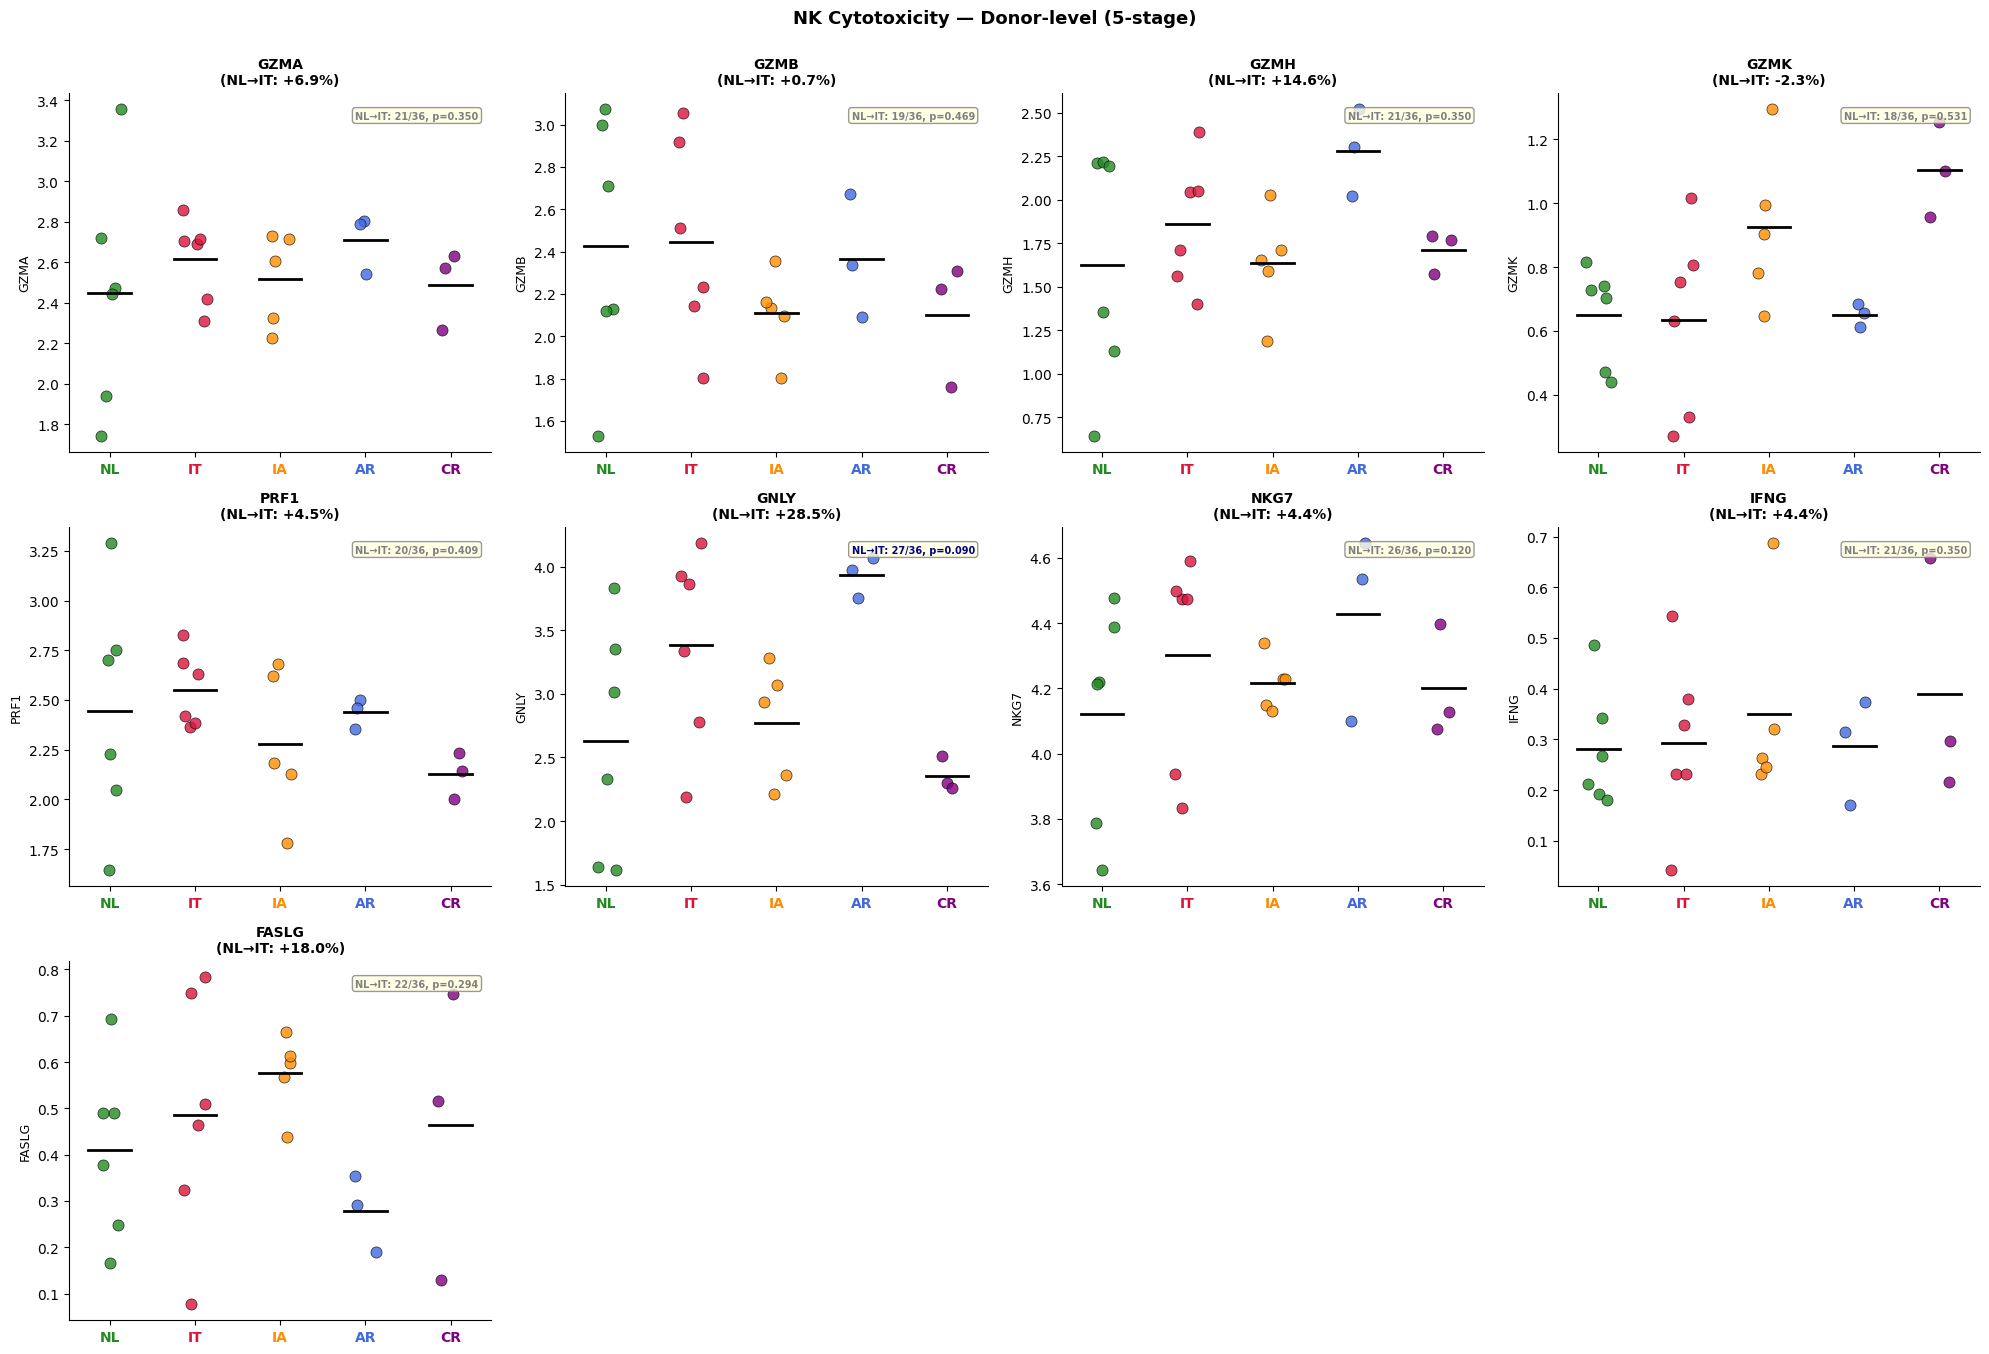

  Saved: SupFig_NK_Cytotoxicity_DonorLevel

--- NK Function Genes ---

Gene         |              NL→IT |              NL→CR |              IT→IA |              IA→AR
  -------------------------------------------------------------------------------------
  KLRD1        |       -0% 21/36    |       -9% 13/18    |      -15% 29/30 ** |       +7% 11/15   
  KLRF1        |       -1% 19/36    |      -13% 14/18    |      -19% 29/30 ** |       -6% 10/15   
  KLRC1        |       +6% 22/36    |      +64% 17/18 ** |      +17% 18/30    |      -16% 10/15   
  KLRC2        |       -7% 18/36    |      -48% 14/18    |      -42% 24/30 *  |      +43% 12/15   
  KLRK1        |       -6% 21/36    |      -35% 14/18    |      -48% 26/30 ** |      +75% 10/15   
  NCR1         |      +22% 24/36    |      +34% 16/18 ** |       -2% 16/30    |      -21% 10/15   
  NCR3         |       +5% 18/36    |        -8% 9/18    |      -10% 17/30    |      +21% 12/15   
  FCGR3A       |      +20% 24/36    |      -13% 11/

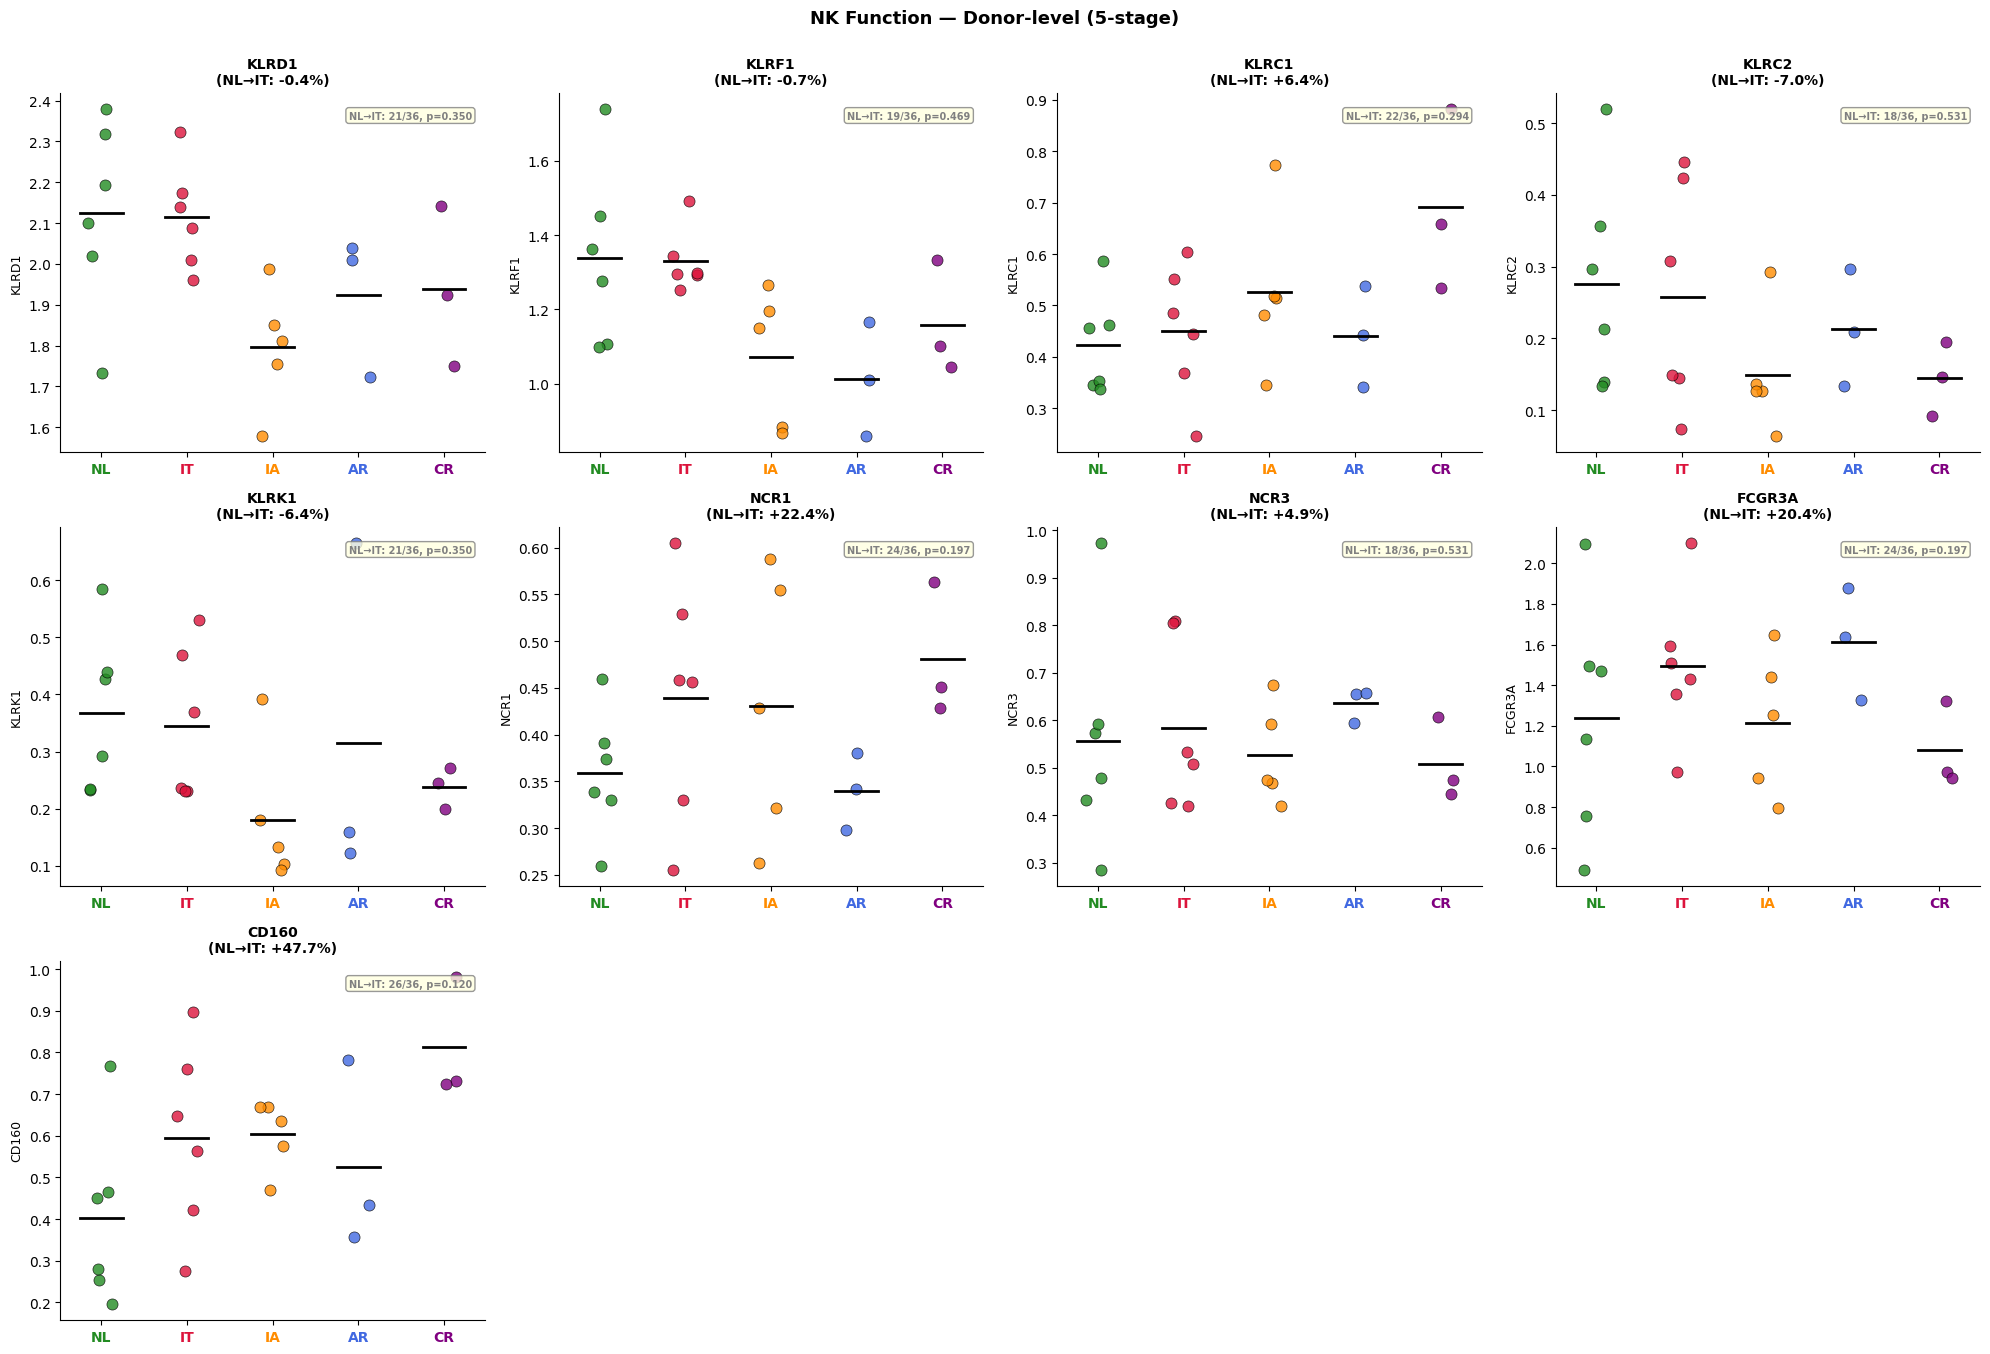

  Saved: SupFig_NK_Function_DonorLevel

--- NK IL-15/mTOR Pathway ---

Gene         |              NL→IT |              NL→CR |              IT→IA |              IA→AR
  -------------------------------------------------------------------------------------
  IL2RB        |      +11% 22/36    |      +12% 12/18    |       +1% 16/30    |      -28% 14/15 **
  IL2RG        |       -5% 18/36    |      -13% 11/18    |       -3% 18/30    |        -1% 8/15   
  IL15RA       |      +28% 29/36 ** |      +27% 15/18 *  |      -17% 21/30    |      +16% 11/15   
  JAK1         |      +32% 32/36 ** |      +45% 18/18 ** |       -0% 15/30    |        -2% 8/15   
  JAK3         |      +56% 28/36 *  |      +47% 15/18 *  |      +18% 20/30    |      +13% 10/15   
  STAT5A       |       -6% 20/36    |       +4% 10/18    |      +12% 18/30    |      -17% 15/15 **
  STAT5B       |      +36% 23/36    |      +32% 13/18    |      +11% 16/30    |        +5% 8/15   
  MTOR         |      +67% 34/36 ** |      +82% 18/

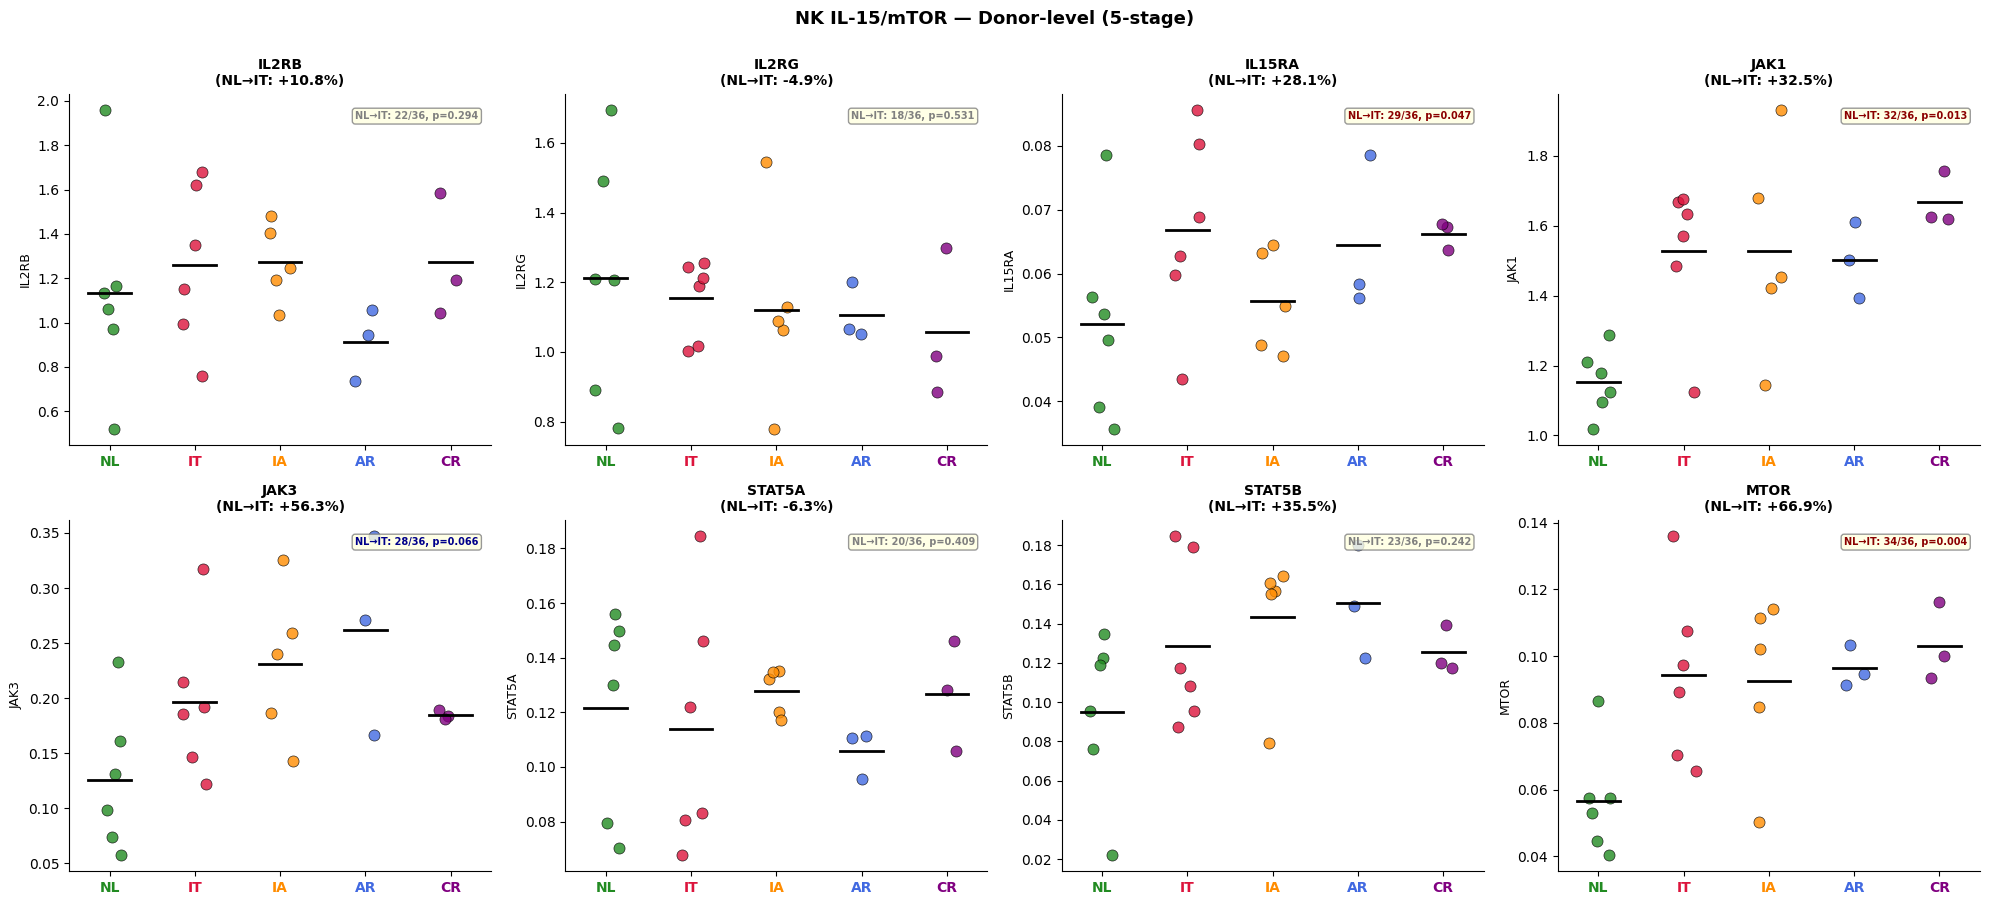

  Saved: SupFig_NK_IL15mTOR_DonorLevel

--- NK Checkpoint/Inhibitory ---

Gene         |              NL→IT |              NL→CR |              IT→IA |              IA→AR
  -------------------------------------------------------------------------------------
  PDCD1        |      +68% 28/36 *  |      +18% 11/18    |      +56% 21/30    |      -45% 11/15   
  HAVCR2       |       +0% 19/36    |       -6% 11/18    |      -10% 17/30    |      -39% 15/15 **
  TIGIT        |      +14% 24/36    |      +24% 11/18    |       +5% 16/30    |      -29% 15/15 **
  LAG3         |      -24% 22/36    |      -43% 12/18    |       -4% 17/30    |       -9% 10/15   
  KLRC1        |       +6% 22/36    |      +64% 17/18 ** |      +17% 18/30    |      -16% 10/15   
  CD96         |       +4% 19/36    |      +28% 15/18 *  |       +4% 19/30    |      -22% 15/15 **
  SIGLEC7      |      +28% 24/36    |      +35% 11/18    |      -16% 18/30    |        -0% 9/15   


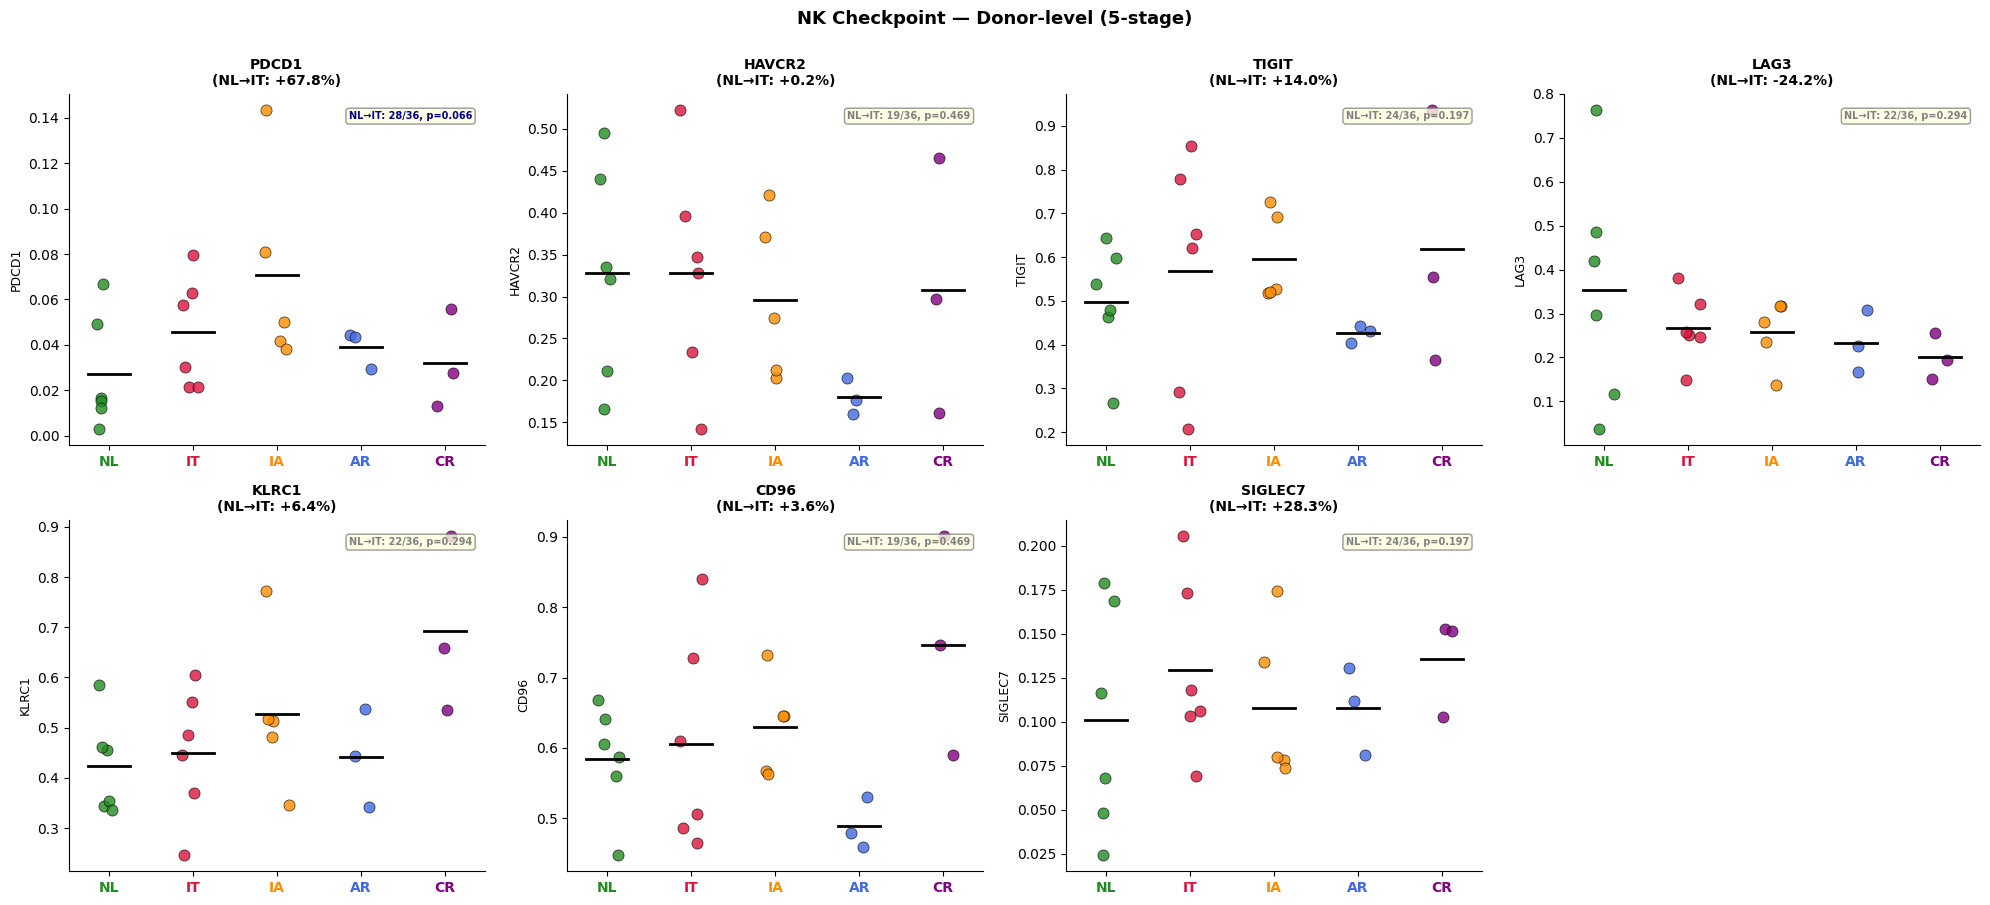

  Saved: SupFig_NK_Checkpoint_DonorLevel


In [30]:
# ============================================================
# NK CELL ANALYSIS
# ============================================================
print("\n" + "="*80)
print("NK CELL — COMPREHENSIVE DONOR-LEVEL VALIDATION")
print("="*80)

nk_mask = adata.obs['major_lineage'] == 'NK'
adata_nk = adata[nk_mask]

for stage in STAGE_ORDER:
    n = (adata_nk.obs['Stage'] == stage).sum()
    d = adata_nk.obs[adata_nk.obs['Stage'] == stage]['donor_id'].nunique()
    print(f"  {stage}: {n} cells, {d} donors")

# NK cytotoxicity genes
NK_CYTO_GENES = ['GZMA', 'GZMB', 'GZMH', 'GZMK', 'PRF1', 'GNLY', 'NKG7', 'IFNG', 'FASLG']
print("\n--- NK Cytotoxicity Genes ---")
nk_cyto = run_battery_with_stats(adata_nk, NK_CYTO_GENES, 'NK Cytotoxicity',
                                  'SupFig_NK_Cytotoxicity_DonorLevel')

# NK function genes
NK_FUNC_GENES = ['KLRD1', 'KLRF1', 'KLRC1', 'KLRC2', 'KLRK1', 'NCR1', 'NCR3',
                  'FCGR3A', 'CD160']
print("\n--- NK Function Genes ---")
nk_func = run_battery_with_stats(adata_nk, NK_FUNC_GENES, 'NK Function',
                                  'SupFig_NK_Function_DonorLevel')

# NK receptor / IL-15 pathway (some already done but need full pairwise)
NK_IL15_GENES = ['IL2RB', 'IL2RG', 'IL15RA', 'JAK1', 'JAK3', 'STAT5A', 'STAT5B', 'MTOR']
print("\n--- NK IL-15/mTOR Pathway ---")
nk_il15 = run_battery_with_stats(adata_nk, NK_IL15_GENES, 'NK IL-15/mTOR',
                                  'SupFig_NK_IL15mTOR_DonorLevel')

# NK checkpoint / exhaustion
NK_CHECK_GENES = ['PDCD1', 'HAVCR2', 'TIGIT', 'LAG3', 'KLRC1', 'CD96', 'SIGLEC7']
print("\n--- NK Checkpoint/Inhibitory ---")
nk_check = run_battery_with_stats(adata_nk, NK_CHECK_GENES, 'NK Checkpoint',
                                   'SupFig_NK_Checkpoint_DonorLevel')


CD8 T CELL — COMPREHENSIVE DONOR-LEVEL VALIDATION
  NL: 11974 cells, 6 donors
  IT: 10938 cells, 6 donors
  IA: 20857 cells, 5 donors
  AR: 15809 cells, 3 donors
  CR: 10487 cells, 3 donors

--- CD8_T Checkpoint/Exhaustion ---

Gene         |              NL→IT |              NL→CR |              IT→IA |              IA→AR
  -------------------------------------------------------------------------------------
  PDCD1        |      +33% 24/36    |       -8% 10/18    |     +123% 28/30 ** |      -49% 14/15 **
  LAG3         |      -10% 19/36    |      -29% 11/18    |      +72% 26/30 ** |      -36% 12/15   
  HAVCR2       |      -16% 19/36    |      -60% 14/18    |     +273% 28/30 ** |       -11% 8/15   
  TIGIT        |      +63% 28/36 *  |      +13% 10/18    |      +81% 26/30 ** |      -30% 12/15   
  TOX          |      +40% 26/36    |      +10% 12/18    |      +73% 28/30 ** |      -34% 15/15 **
  TOX2         |      +14% 19/36    |      +11% 12/18    |     +266% 30/30 ** |      -56% 1

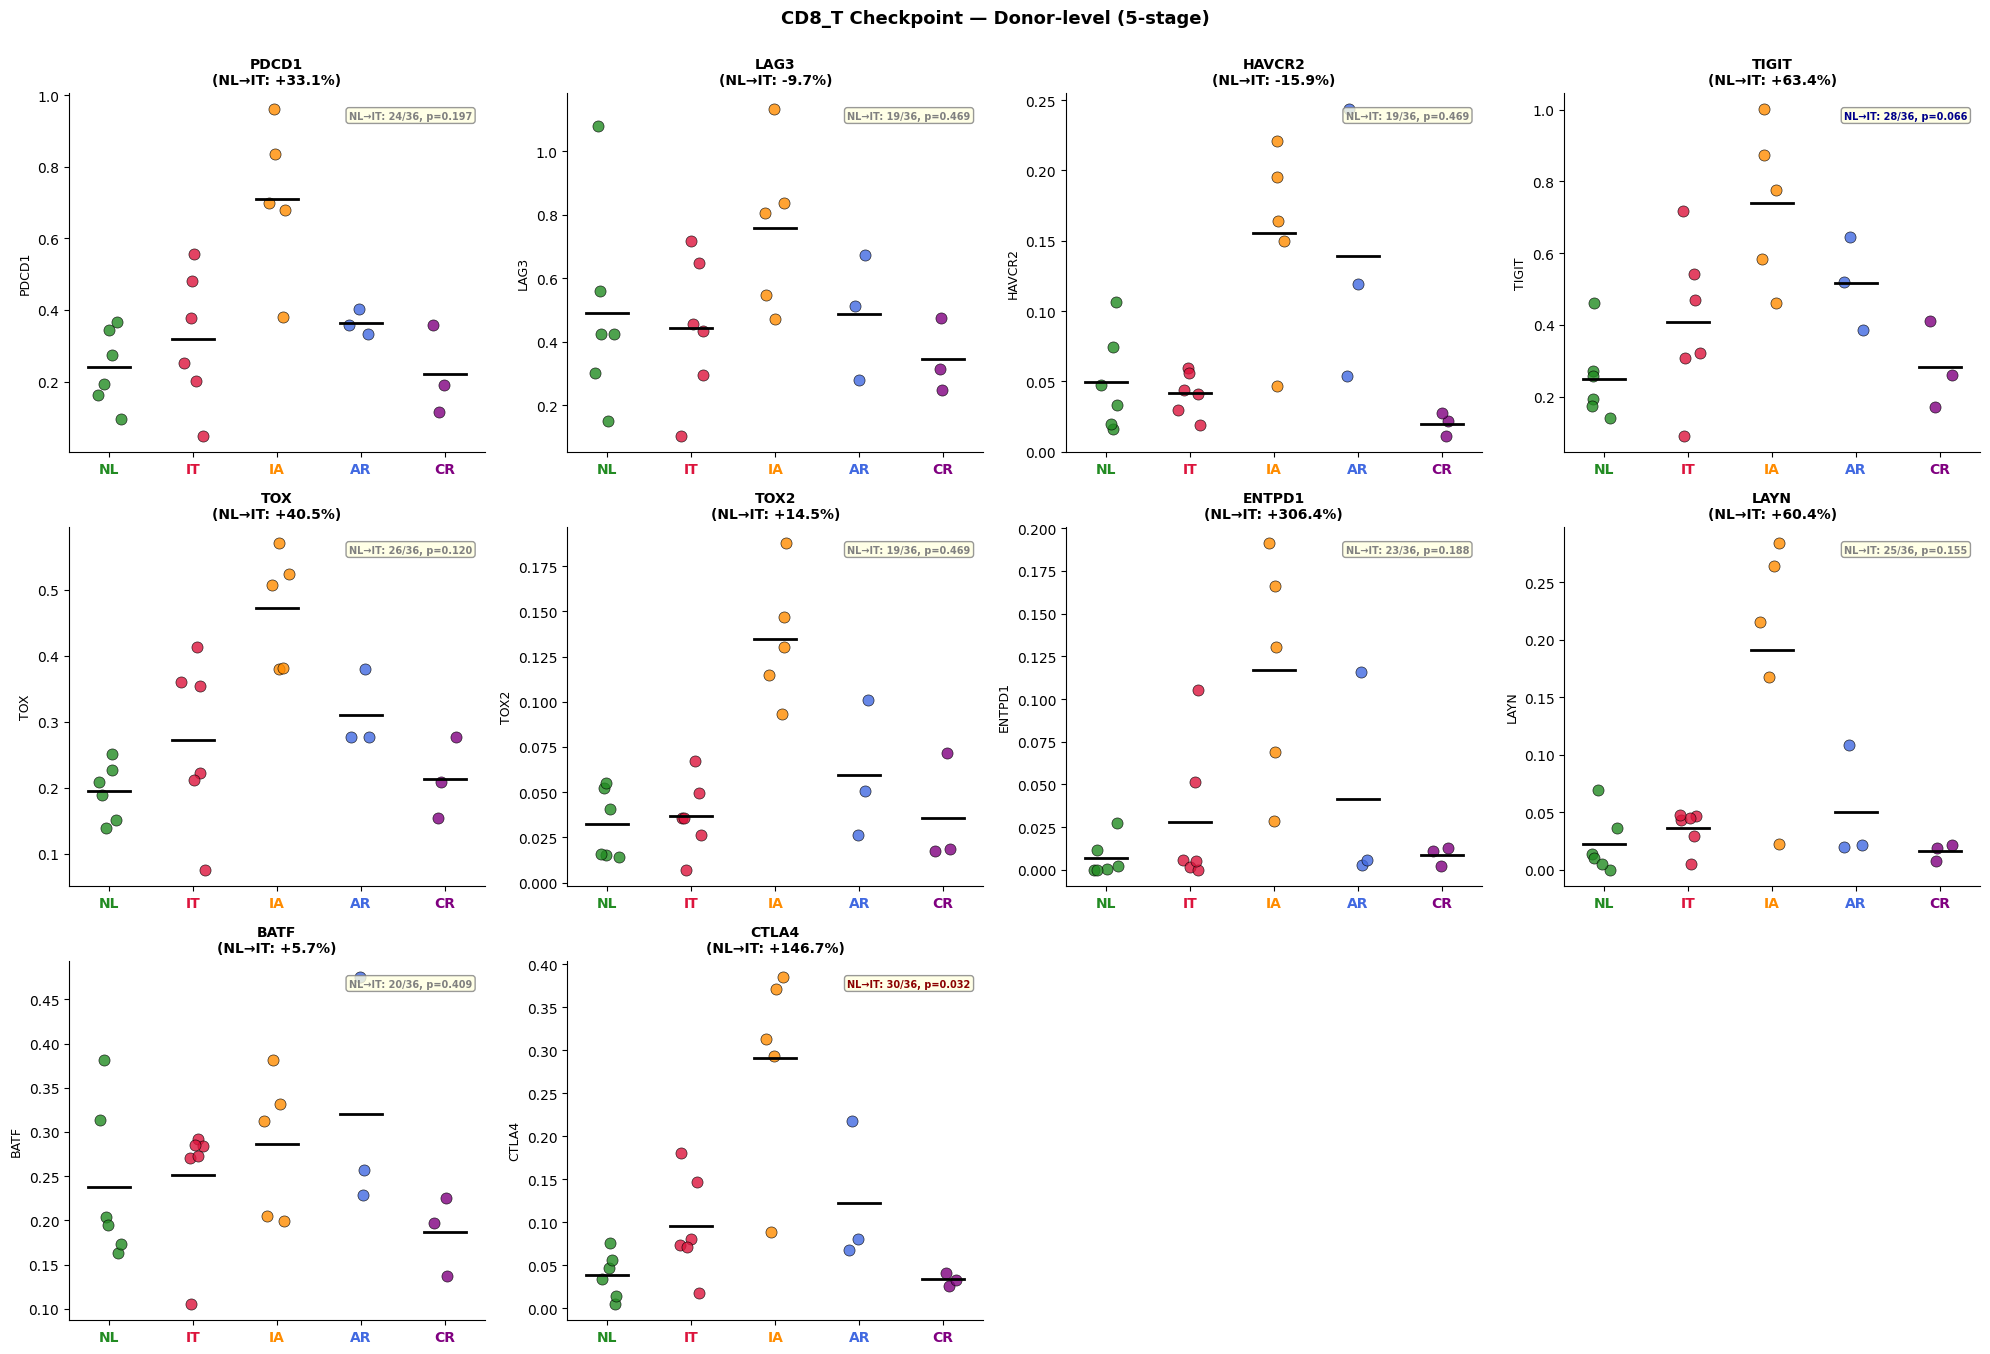

  Saved: SupFig_CD8T_Checkpoint_DonorLevel

--- CD8_T Effector ---

Gene         |              NL→IT |              NL→CR |              IT→IA |              IA→AR
  -------------------------------------------------------------------------------------
  GZMB         |      -14% 19/36    |       -2% 10/18    |      -26% 20/30    |     +100% 15/15 **
  PRF1         |      -15% 24/36    |      -25% 14/18    |       +3% 17/30    |      +13% 11/15   
  GNLY         |      +53% 23/36    |       +3% 10/18    |      -56% 26/30 ** |     +320% 15/15 **
  IFNG         |       -1% 20/36    |       +1% 10/18    |      +27% 22/30    |       -4% 10/15   
  TNF          |      -38% 25/36    |      -52% 15/18 *  |       +4% 19/30    |      -37% 12/15   
  FASLG        |      -20% 23/36    |      -29% 13/18    |      +64% 26/30 ** |      -45% 15/15 **
  NKG7         |       -4% 19/36    |       +3% 10/18    |      +25% 23/30 *  |        +1% 9/15   


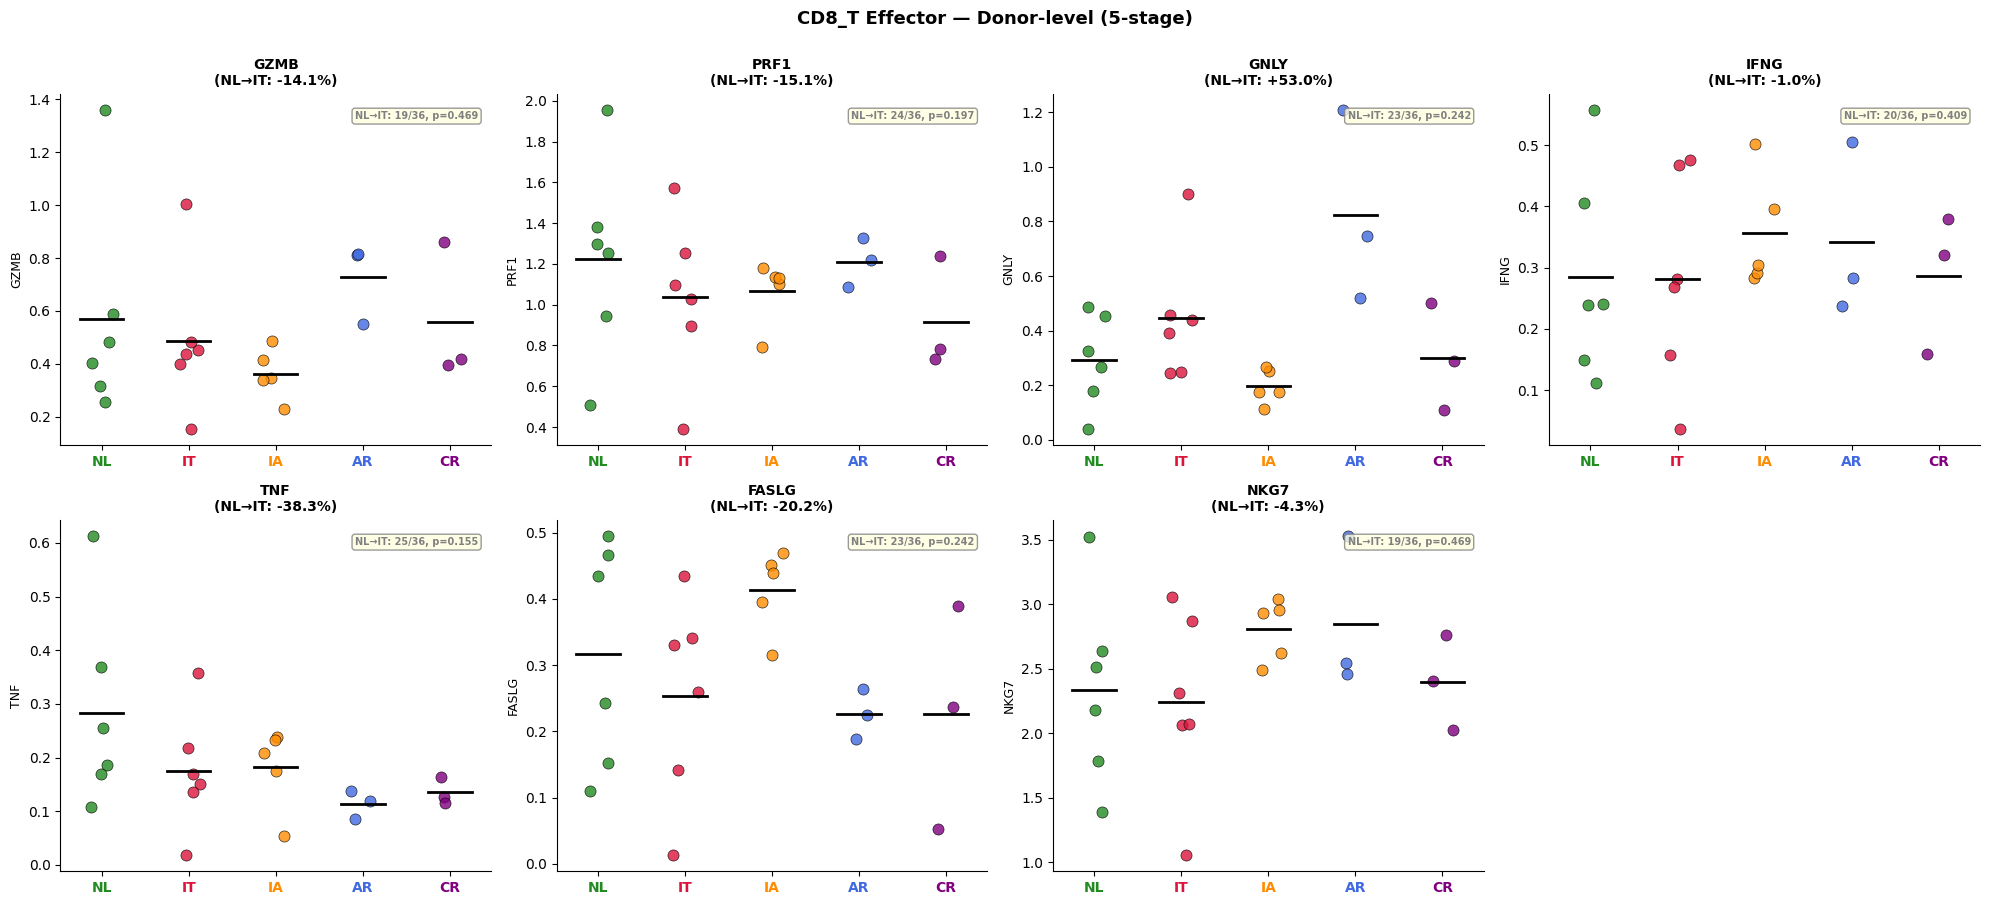

  Saved: SupFig_CD8T_Effector_DonorLevel

--- CD8_T Naive/Memory ---

Gene         |              NL→IT |              NL→CR |              IT→IA |              IA→AR
  -------------------------------------------------------------------------------------
  CCR7         |      +81% 28/36 *  |      +52% 14/18    |      -37% 22/30    |        +6% 8/15   
  SELL         |      +99% 27/36 *  |      +81% 13/18    |      -57% 24/30 *  |      +73% 11/15   
  LEF1         |     +122% 29/36 ** |      +92% 14/18    |      -57% 22/30    |      +58% 11/15   
  TCF7         |     +134% 32/36 ** |     +107% 15/18 *  |      -38% 22/30    |       +16% 9/15   
  IL7R         |       -7% 19/36    |      -16% 11/18    |      -42% 28/30 ** |        +6% 8/15   
  CD27         |     +115% 34/36 ** |      +77% 16/18 ** |      +14% 19/30    |      +15% 10/15   
  CD28         |      +23% 23/36    |      +25% 14/18    |       +9% 17/30    |      -31% 13/15 * 


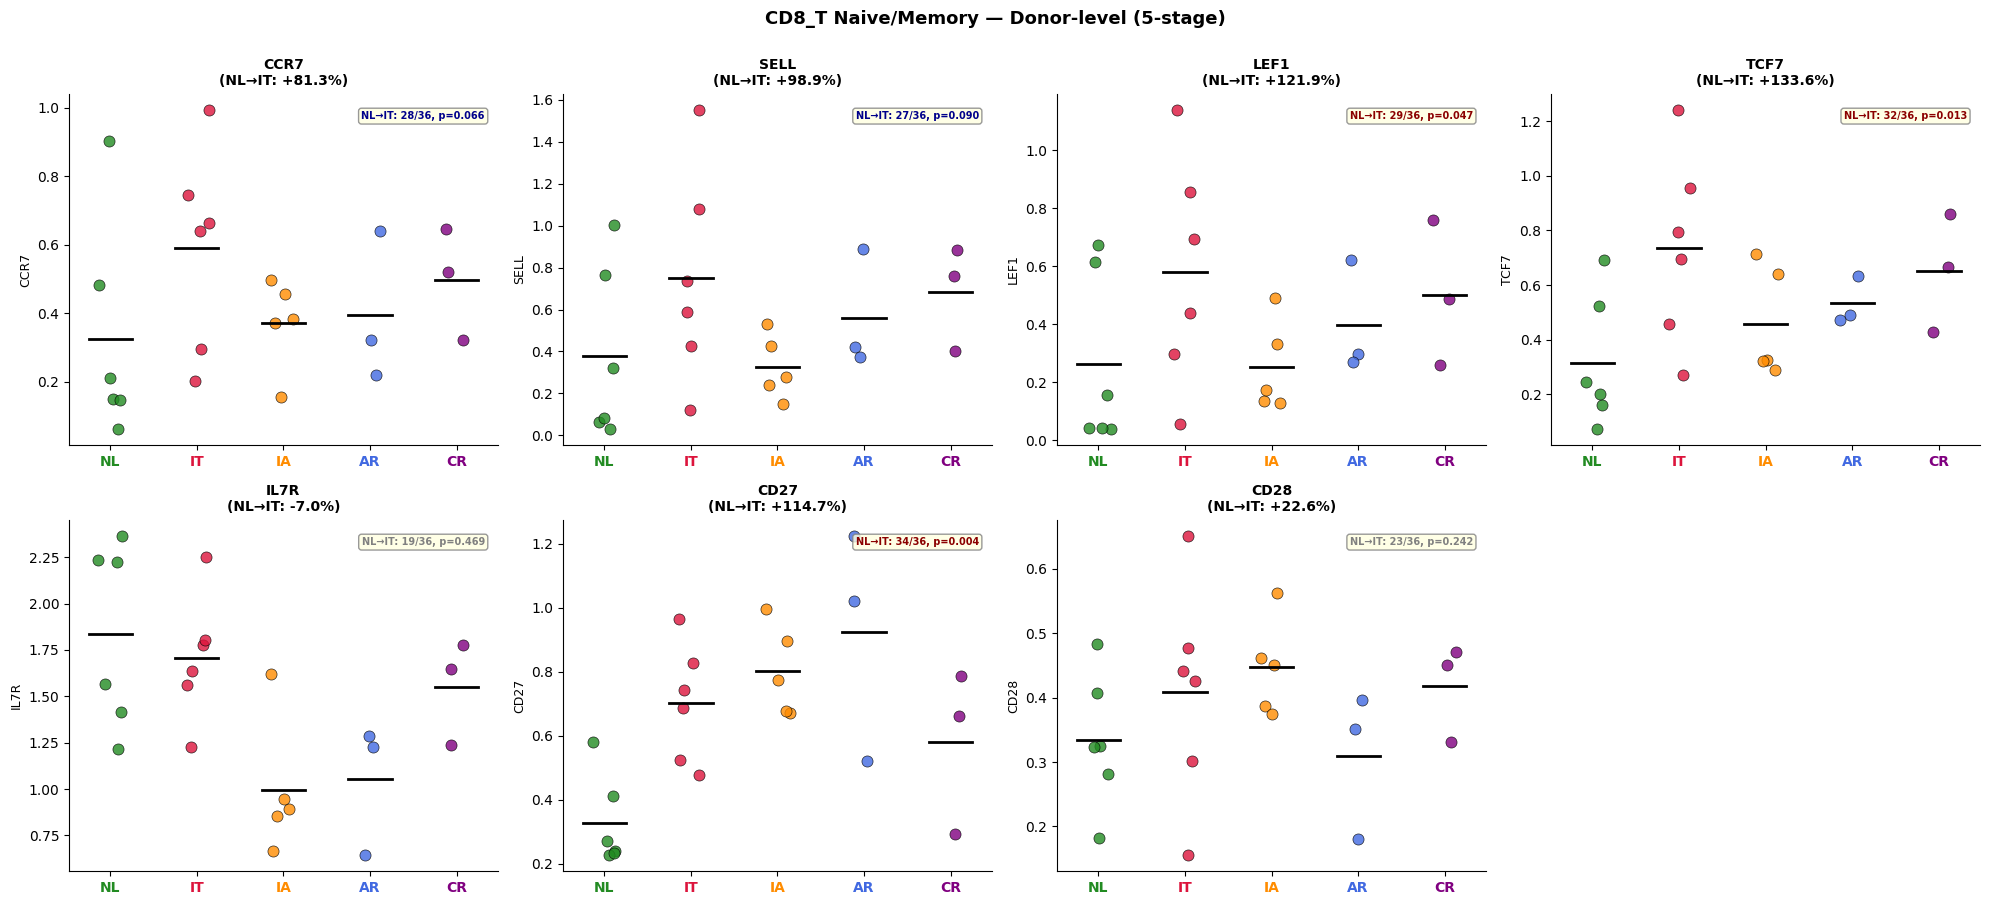

  Saved: SupFig_CD8T_NaiveMemory_DonorLevel


In [35]:
# ============================================================
# CD8 T CELL ANALYSIS
# ============================================================
print("\n" + "="*80)
print("CD8 T CELL — COMPREHENSIVE DONOR-LEVEL VALIDATION")
print("="*80)

cd8_mask = adata.obs['major_lineage'] == 'CD8_T'
adata_cd8 = adata[cd8_mask]

for stage in STAGE_ORDER:
    n = (adata_cd8.obs['Stage'] == stage).sum()
    d = adata_cd8.obs[adata_cd8.obs['Stage'] == stage]['donor_id'].nunique()
    print(f"  {stage}: {n} cells, {d} donors")

# CD8 checkpoint/exhaustion — CORE claim
CD8_CHECK_GENES = ['PDCD1', 'LAG3', 'HAVCR2', 'TIGIT', 'TOX', 'TOX2',
                    'ENTPD1', 'LAYN', 'BATF', 'CTLA4']
print("\n--- CD8_T Checkpoint/Exhaustion ---")
cd8_check = run_battery_with_stats(adata_cd8, CD8_CHECK_GENES, 'CD8_T Checkpoint',
                                    'SupFig_CD8T_Checkpoint_DonorLevel')

# CD8 effector genes
CD8_EFF_GENES = ['GZMB', 'PRF1', 'GNLY', 'IFNG', 'TNF', 'FASLG', 'NKG7']
print("\n--- CD8_T Effector ---")
cd8_eff = run_battery_with_stats(adata_cd8, CD8_EFF_GENES, 'CD8_T Effector',
                                  'SupFig_CD8T_Effector_DonorLevel')

# CD8 naive/memory markers
CD8_NM_GENES = ['CCR7', 'SELL', 'LEF1', 'TCF7', 'IL7R', 'CD27', 'CD28']
print("\n--- CD8_T Naive/Memory ---")
cd8_nm = run_battery_with_stats(adata_cd8, CD8_NM_GENES, 'CD8_T Naive/Memory',
                                 'SupFig_CD8T_NaiveMemory_DonorLevel')


CD4 T CELL — COMPREHENSIVE DONOR-LEVEL VALIDATION
  NL: 8648 cells, 6 donors
  IT: 14591 cells, 6 donors
  IA: 18380 cells, 5 donors
  AR: 13528 cells, 3 donors
  CR: 14299 cells, 3 donors

--- CD4_T Key Genes ---

Gene         |              NL→IT |              NL→CR |              IT→IA |              IA→AR
  -------------------------------------------------------------------------------------
  FOXP3        |      +86% 29/36 ** |       +2% 10/18    |      +35% 23/30 *  |      -50% 15/15 **
  IL2RA        |       +4% 21/36    |       -4% 12/18    |      -19% 21/30    |       +9% 10/15   
  CTLA4        |      +71% 27/36 *  |      +19% 12/18    |      +31% 22/30    |      -38% 12/15   
  TNFRSF4      |      +12% 18/36    |      -20% 12/18    |      +16% 19/30    |      -35% 11/15   
  TNFRSF18     |      -10% 21/36    |      -45% 15/18 *  |      +25% 20/30    |      -46% 11/15   
  TBX21        |       -3% 20/36    |      -37% 12/18    |       +5% 17/30    |      -46% 13/15 * 
  GAT

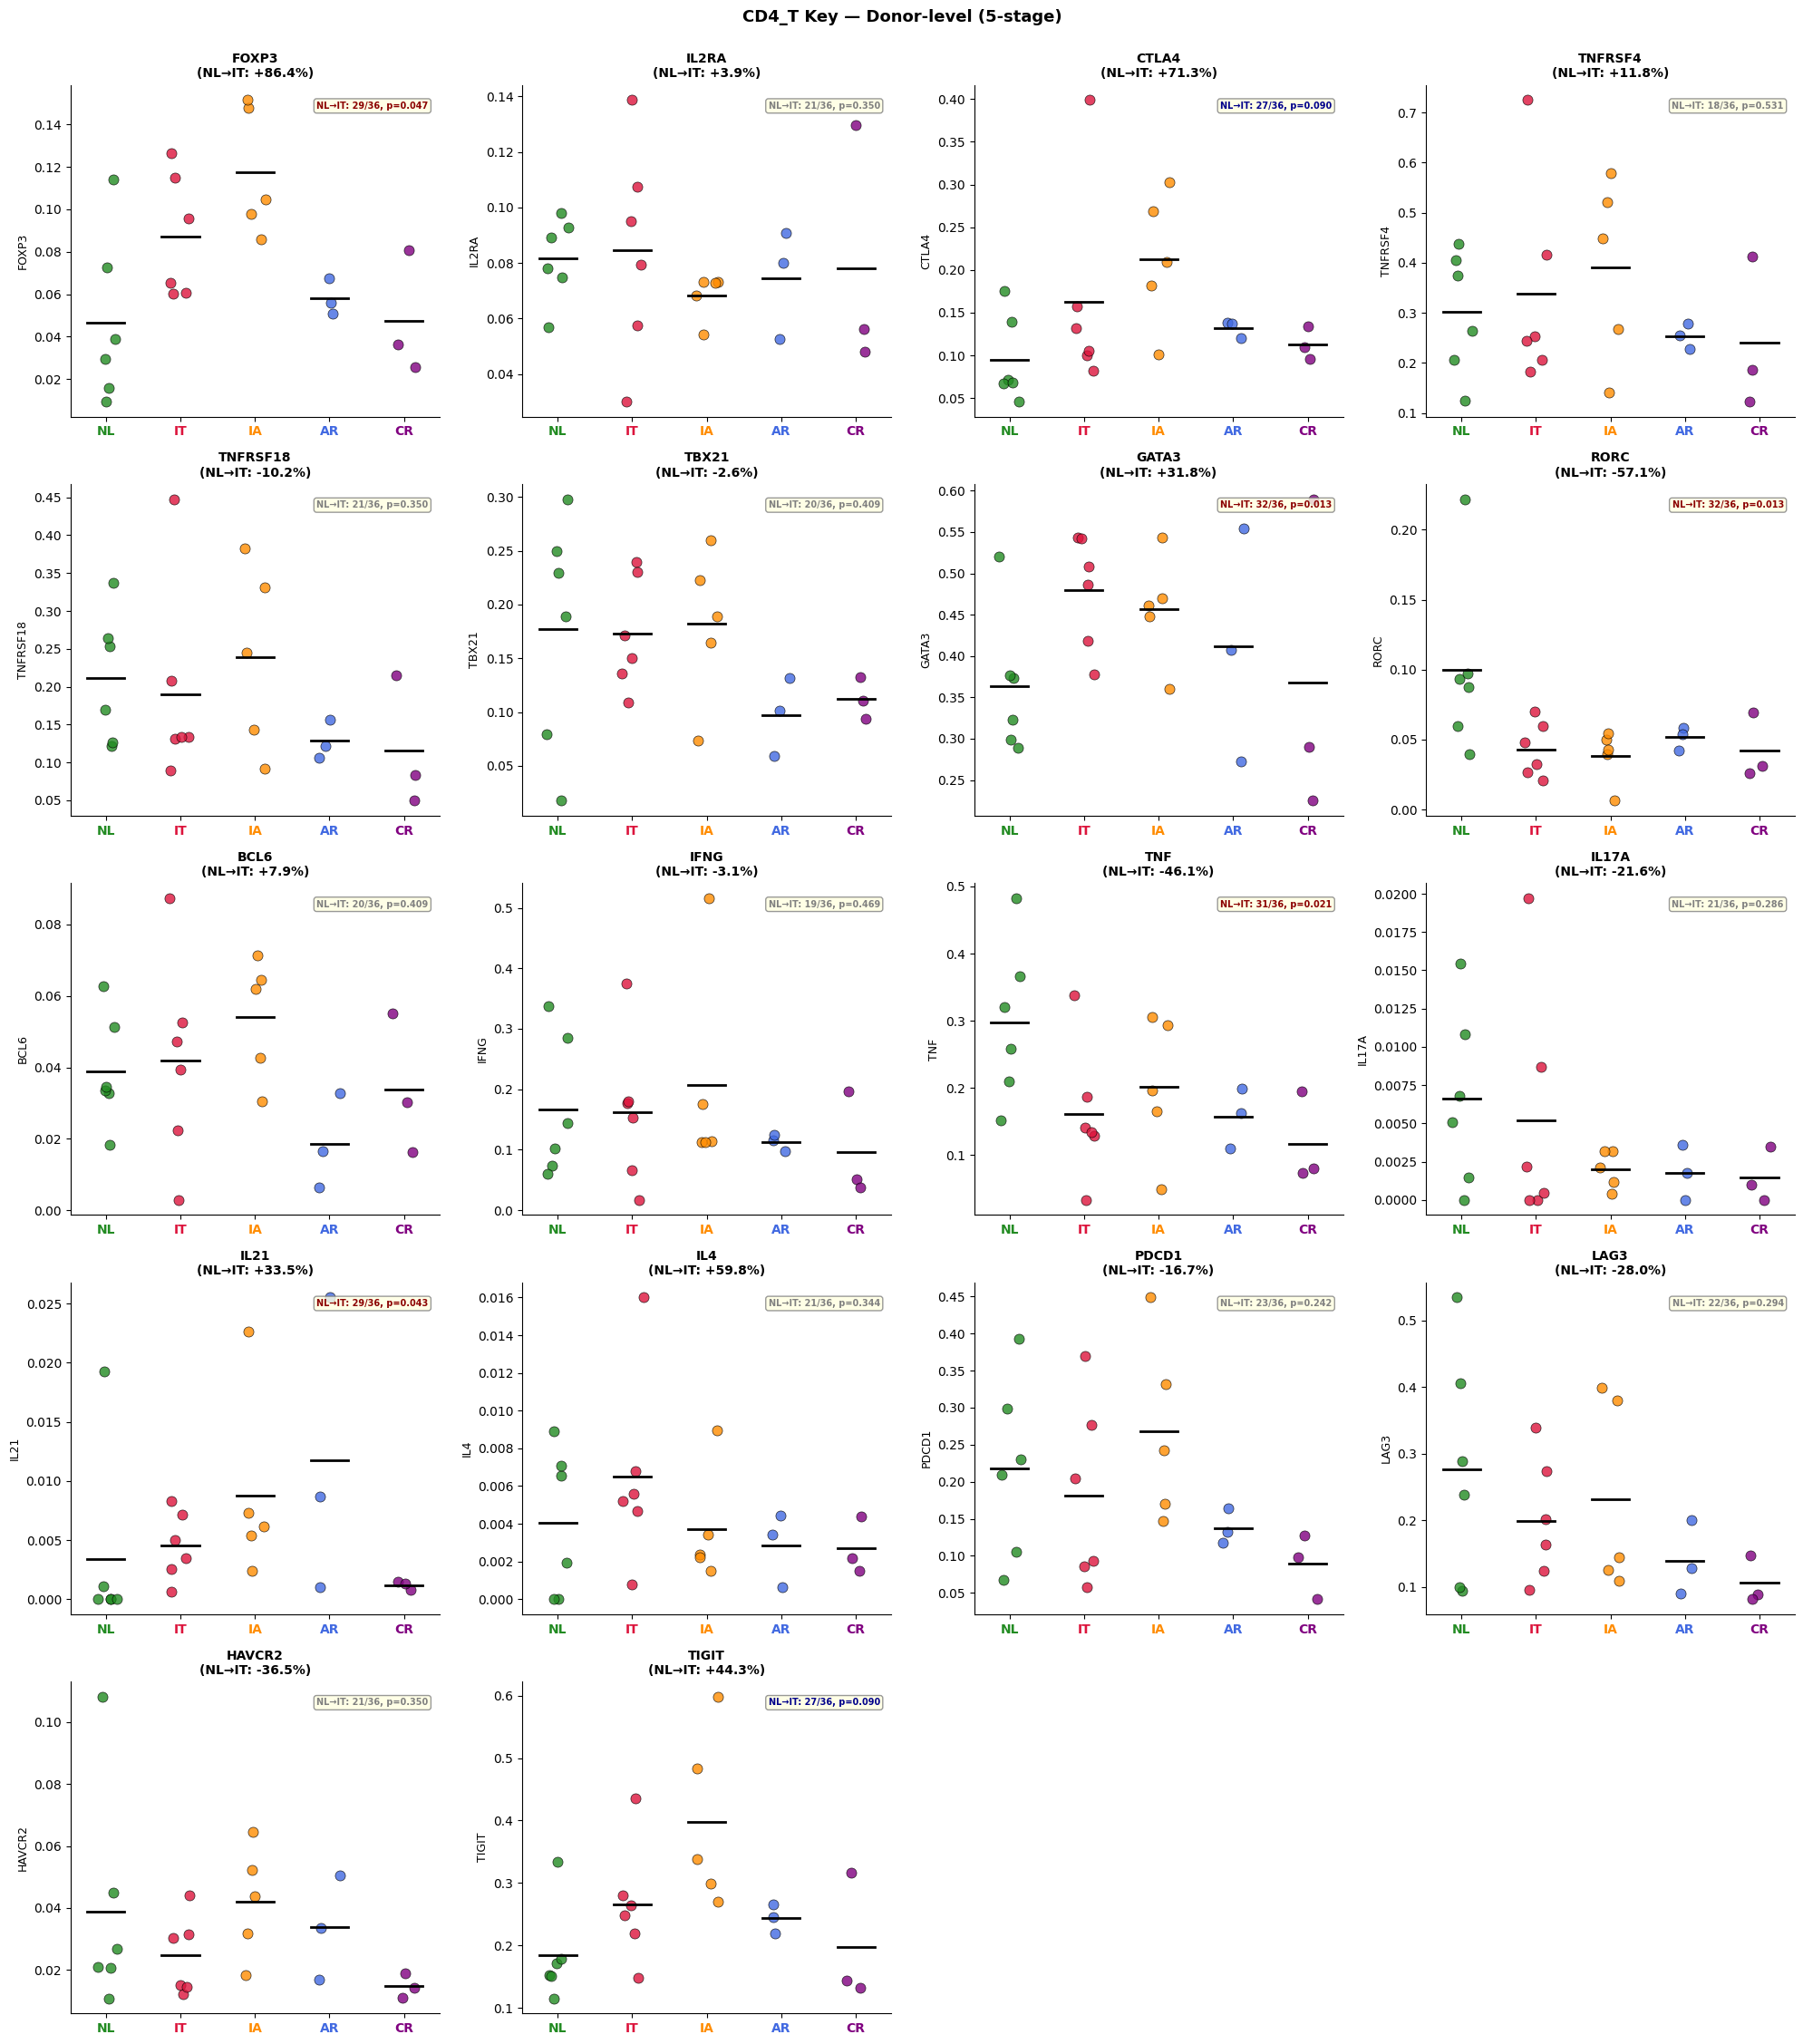

  Saved: SupFig_CD4T_KeyGenes_DonorLevel


In [32]:
# ============================================================
# CD4 T CELL ANALYSIS
# ============================================================
print("\n" + "="*80)
print("CD4 T CELL — COMPREHENSIVE DONOR-LEVEL VALIDATION")
print("="*80)

cd4_mask = adata.obs['major_lineage'] == 'CD4_T'
adata_cd4 = adata[cd4_mask]

for stage in STAGE_ORDER:
    n = (adata_cd4.obs['Stage'] == stage).sum()
    d = adata_cd4.obs[adata_cd4.obs['Stage'] == stage]['donor_id'].nunique()
    print(f"  {stage}: {n} cells, {d} donors")

# CD4 key functional genes
CD4_KEY_GENES = ['FOXP3', 'IL2RA', 'CTLA4', 'TNFRSF4', 'TNFRSF18',  # Treg
                  'TBX21', 'GATA3', 'RORC', 'BCL6',                    # TF
                  'IFNG', 'TNF', 'IL17A', 'IL21', 'IL4',               # Cytokines
                  'PDCD1', 'LAG3', 'HAVCR2', 'TIGIT']                  # Checkpoint
print("\n--- CD4_T Key Genes ---")
cd4_key = run_battery_with_stats(adata_cd4, CD4_KEY_GENES, 'CD4_T Key',
                                  'SupFig_CD4T_KeyGenes_DonorLevel')

In [42]:
# ============================================================
# 3. COMPUTE PROPORTION PER SAMPLE_ID
# ============================================================
print("\n" + "="*60)
print("LINEAGE PROPORTIONS — FIXED")
print("="*60)

# Total cells per sample_id
totals = adata.obs.groupby('sample_id').size().to_dict()
# Stage per sample_id
stage_map = adata.obs.groupby('sample_id')['Stage'].first().to_dict()

all_stats = []

for lineage in LINEAGES:
    # Lineage cells per sample_id
    lin_counts = adata.obs[adata.obs['major_lineage']==lineage].groupby('sample_id').size().to_dict()

    # Compute proportion for every sample_id
    records = []
    for sid in totals:
        lc = lin_counts.get(sid, 0)
        records.append({
            'sample_id': sid,
            'Stage': stage_map[sid],
            'lineage': lineage,
            'lin_cells': lc,
            'total_cells': totals[sid],
            'pct': lc / totals[sid] * 100
        })
    df = pd.DataFrame(records)

    print(f"\n--- {lineage} ---")
    for stage in STAGE_ORDER:
        sd = df[df['Stage']==stage]['pct']
        if len(sd) > 0:
            print(f"  {stage}: {sd.mean():.1f}% ± {sd.std():.1f}% (n={len(sd)})")

    for sa, sb in [('NL','IT'),('NL','CR'),('IT','IA'),('IA','AR')]:
        va = df[df['Stage']==sa]['pct'].values
        vb = df[df['Stage']==sb]['pct'].values
        r = donor_test(va, vb)
        sig = " **" if r['p']<0.05 else " *" if r['p']<0.1 else ""
        print(f"  {sa}→{sb}: {r['change']}, {r['consist']}/{r['total']} "
              f"(n={r['n_a']}v{r['n_b']}), p={r['p']:.3f}{sig}")
        all_stats.append({
            'lineage':lineage,'comparison':f'{sa}_vs_{sb}',
            'n_a':r['n_a'],'n_b':r['n_b'],'change':r['change'],
            'consistency':r['consist'],'total_pairs':r['total'],
            'p_value':r['p'],'sig_05':r['p']<0.05})


LINEAGE PROPORTIONS — FIXED

--- NK ---
  NL: 37.0% ± 8.9% (n=6)
  IT: 27.7% ± 9.7% (n=6)
  IA: 18.6% ± 6.9% (n=5)
  AR: 20.7% ± 3.7% (n=3)
  CR: 12.7% ± 0.4% (n=3)
  NL→IT: -25.0%, 28/36 (n=6v6), p=0.066 *
  NL→CR: -65.7%, 18/18 (n=6v3), p=0.012 **
  IT→IA: -32.9%, 23/30 (n=6v5), p=0.089 *
  IA→AR: +11.2%, 10/15 (n=5v3), p=0.286

--- CD8_T ---
  NL: 26.3% ± 11.7% (n=6)
  IT: 22.5% ± 10.8% (n=6)
  IA: 34.7% ± 9.1% (n=5)
  AR: 34.5% ± 1.3% (n=3)
  CR: 23.1% ± 7.3% (n=3)
  NL→IT: -14.2%, 25/36 (n=6v6), p=0.155
  NL→CR: -12.1%, 11/18 (n=6v3), p=0.357
  IT→IA: +54.0%, 26/30 (n=6v5), p=0.026 **
  IA→AR: -0.7%, 9/15 (n=5v3), p=0.393

--- CD4_T ---
  NL: 17.8% ± 6.6% (n=6)
  IT: 26.7% ± 12.4% (n=6)
  IA: 27.6% ± 5.3% (n=5)
  AR: 30.1% ± 3.1% (n=3)
  CR: 33.2% ± 3.2% (n=3)
  NL→IT: +49.6%, 24/36 (n=6v6), p=0.197
  NL→CR: +86.0%, 18/18 (n=6v3), p=0.012 **
  IT→IA: +3.6%, 16/30 (n=6v5), p=0.465
  IA→AR: +8.8%, 9/15 (n=5v3), p=0.393

--- Myeloid ---
  NL: 12.0% ± 20.4% (n=6)
  IT: 13.9% ± 8.0% (

In [43]:
#!/usr/bin/env python3
"""
=============================================================================
SCRIPT 2 SAVE CODE — Append to last cell of script2_nk_tcell_donor_validation.py
=============================================================================
Collects all NK / CD8_T / CD4_T results and saves as CSV
"""

import os
CSV_DIR = '/content/drive/MyDrive/ITLAS/results/task3_donor_validation/csv'
os.makedirs(CSV_DIR, exist_ok=True)

# ============================================================
# HELPER: Convert nested results dict to DataFrame
# ============================================================
def results_to_df(all_results, lineage, gene_list, adata_sub):
    """Convert run_battery_with_stats output to clean DataFrame."""
    records = []
    comparisons_list = [('NL','IT'), ('NL','IA'), ('NL','CR'), ('IT','IA'), ('IT','CR'), ('IA','AR')]

    for gene in gene_list:
        if gene not in adata_sub.var_names:
            continue
        if gene not in all_results:
            continue

        res = all_results[gene]
        for sa, sb in comparisons_list:
            key = f"{sa}_{sb}"
            if key not in res:
                continue
            r = res[key]
            records.append({
                'lineage': lineage,
                'gene': gene,
                'comparison': f'{sa}_vs_{sb}',
                'mean_a': r['va'].mean() if len(r['va']) > 0 else np.nan,
                'mean_b': r['vb'].mean() if len(r['vb']) > 0 else np.nan,
                'n_a': len(r['va']),
                'n_b': len(r['vb']),
                'pct_change': r['change'],
                'direction': r['direction'],
                'consistency': r['consist'],
                'total_pairs': r['total'],
                'consistency_pct': round(r['consist']/r['total']*100, 1) if r['total'] > 0 else 0,
                'p_value': r['p'],
                'sig_05': r['p'] < 0.05,
                'sig_10': r['p'] < 0.10,
            })
    return pd.DataFrame(records)

# ============================================================
# HELPER: Save raw donor-level expression
# ============================================================
def save_raw_donor(adata_sub, gene_list, lineage):
    records = []
    for gene in gene_list:
        if gene not in adata_sub.var_names:
            continue
        donor_df = get_donor_means(adata_sub, gene)
        if donor_df is not None:
            donor_df['gene'] = gene
            donor_df['lineage'] = lineage
            records.append(donor_df)
    if records:
        return pd.concat(records, ignore_index=True)
    return pd.DataFrame()

# ============================================================
# 1. NK CELL — All results
# ============================================================
print("\n" + "="*80)
print("SAVING NK / CD8_T / CD4_T RESULTS AS CSV")
print("="*80)

nk_all_genes = list(set(NK_CYTO_GENES + NK_FUNC_GENES + NK_IL15_GENES + NK_CHECK_GENES))
nk_stat_dfs = []
nk_stat_dfs.append(results_to_df(nk_cyto, 'NK', NK_CYTO_GENES, adata_nk))
nk_stat_dfs.append(results_to_df(nk_func, 'NK', NK_FUNC_GENES, adata_nk))
nk_stat_dfs.append(results_to_df(nk_il15, 'NK', NK_IL15_GENES, adata_nk))
nk_stat_dfs.append(results_to_df(nk_check, 'NK', NK_CHECK_GENES, adata_nk))
nk_stat_df = pd.concat(nk_stat_dfs, ignore_index=True)

nk_raw_df = save_raw_donor(adata_nk, nk_all_genes, 'NK')

# ============================================================
# 2. CD8_T — All results
# ============================================================
cd8_all_genes = list(set(CD8_CHECK_GENES + CD8_EFF_GENES + CD8_NM_GENES))
cd8_stat_dfs = []
cd8_stat_dfs.append(results_to_df(cd8_check, 'CD8_T', CD8_CHECK_GENES, adata_cd8))
cd8_stat_dfs.append(results_to_df(cd8_eff, 'CD8_T', CD8_EFF_GENES, adata_cd8))
cd8_stat_dfs.append(results_to_df(cd8_nm, 'CD8_T', CD8_NM_GENES, adata_cd8))
cd8_stat_df = pd.concat(cd8_stat_dfs, ignore_index=True)

cd8_raw_df = save_raw_donor(adata_cd8, cd8_all_genes, 'CD8_T')

# ============================================================
# 3. CD4_T — All results
# ============================================================
cd4_all_genes = [g for g in CD4_KEY_GENES if g in adata_cd4.var_names]
cd4_stat_df = results_to_df(cd4_key, 'CD4_T', CD4_KEY_GENES, adata_cd4)

cd4_raw_df = save_raw_donor(adata_cd4, cd4_all_genes, 'CD4_T')

# ============================================================
# 4. LINEAGE PROPORTIONS — Save
# ============================================================
prop_records = []
all_total = adata.obs.groupby(['donor_id', 'Stage']).size().reset_index(name='total')

for lineage in LINEAGES:
    lin_counts = adata.obs[adata.obs['major_lineage'] == lineage].groupby(
        ['donor_id', 'Stage']).size().reset_index(name='lin_cells')
    merged = all_total.merge(lin_counts, on=['donor_id', 'Stage'], how='left')
    merged['lin_cells'] = merged['lin_cells'].fillna(0)
    merged['proportion_pct'] = merged['lin_cells'] / merged['total'] * 100
    merged['lineage'] = lineage
    prop_records.append(merged[['donor_id', 'Stage', 'lineage', 'lin_cells', 'total', 'proportion_pct']])

prop_all_df = pd.concat(prop_records, ignore_index=True)

# Proportion statistics
prop_stat_records = []
for lineage in LINEAGES:
    lp = prop_all_df[prop_all_df['lineage'] == lineage].copy()
    lp['expression'] = lp['proportion_pct']
    for sa, sb in [('NL','IT'), ('NL','CR'), ('IT','IA'), ('IA','AR')]:
        va = lp[lp['Stage'] == sa]['expression'].values
        vb = lp[lp['Stage'] == sb]['expression'].values
        if len(va) < 2 or len(vb) < 2:
            continue
        _, p_gt = mannwhitneyu(va, vb, alternative='greater')
        _, p_lt = mannwhitneyu(va, vb, alternative='less')
        if p_gt < p_lt:
            consist = sum(1 for a in va for b in vb if a > b)
            direction = f'{sa}>{sb}'
            p_use = p_gt
        else:
            consist = sum(1 for a in va for b in vb if a < b)
            direction = f'{sb}>{sa}'
            p_use = p_lt
        total_pairs = len(va) * len(vb)
        change = (vb.mean() - va.mean()) / va.mean() * 100 if va.mean() > 0 else float('inf')
        prop_stat_records.append({
            'lineage': lineage, 'metric': 'proportion_pct',
            'comparison': f'{sa}_vs_{sb}',
            'mean_a': va.mean(), 'mean_b': vb.mean(),
            'n_a': len(va), 'n_b': len(vb),
            'pct_change': change, 'direction': direction,
            'consistency': consist, 'total_pairs': total_pairs,
            'consistency_pct': round(consist/total_pairs*100, 1),
            'p_value': p_use, 'sig_05': p_use < 0.05, 'sig_10': p_use < 0.10,
        })

prop_stat_df = pd.DataFrame(prop_stat_records)

# ============================================================
# 5. SAVE ALL CSV FILES
# ============================================================

# Combined statistics
all_stat = pd.concat([nk_stat_df, cd8_stat_df, cd4_stat_df], ignore_index=True)
all_stat.to_csv(os.path.join(CSV_DIR, 'nk_tcell_donor_statistics.csv'), index=False)
print(f"  Saved: nk_tcell_donor_statistics.csv ({all_stat.shape})")

# Combined raw expression
all_raw = pd.concat([nk_raw_df, cd8_raw_df, cd4_raw_df], ignore_index=True)
all_raw.to_csv(os.path.join(CSV_DIR, 'nk_tcell_donor_raw_expression.csv'), index=False)
print(f"  Saved: nk_tcell_donor_raw_expression.csv ({all_raw.shape})")

# Proportions
prop_all_df.to_csv(os.path.join(CSV_DIR, 'lineage_proportions_donor.csv'), index=False)
print(f"  Saved: lineage_proportions_donor.csv ({prop_all_df.shape})")

prop_stat_df.to_csv(os.path.join(CSV_DIR, 'lineage_proportions_statistics.csv'), index=False)
print(f"  Saved: lineage_proportions_statistics.csv ({prop_stat_df.shape})")

# Per-lineage files for convenience
nk_stat_df.to_csv(os.path.join(CSV_DIR, 'nk_donor_statistics.csv'), index=False)
cd8_stat_df.to_csv(os.path.join(CSV_DIR, 'cd8t_donor_statistics.csv'), index=False)
cd4_stat_df.to_csv(os.path.join(CSV_DIR, 'cd4t_donor_statistics.csv'), index=False)
print(f"  Saved: nk/cd8t/cd4t_donor_statistics.csv")

# Summary: significant findings
print(f"\n--- SIGNIFICANT (p<0.05) SUMMARY ---")
for name, df in [('NK', nk_stat_df), ('CD8_T', cd8_stat_df), ('CD4_T', cd4_stat_df)]:
    sig = df[df['sig_05']]
    print(f"  {name}: {len(sig)}/{len(df)} significant")
    for _, row in sig.iterrows():
        ch = f"{row['pct_change']:+.0f}%" if abs(row['pct_change']) < 9999 else "INF"
        print(f"    {row['gene']:12s} {row['comparison']:12s} {ch:>8s} "
              f"{row['consistency']}/{row['total_pairs']} p={row['p_value']:.3f}")

print(f"\n  Proportion statistics:")
for _, row in prop_stat_df[prop_stat_df['sig_05']].iterrows():
    print(f"    {row['lineage']:10s} {row['comparison']:12s} {row['pct_change']:+.1f}% "
          f"{row['consistency']}/{row['total_pairs']} p={row['p_value']:.3f}")

print("\n  ALL Script 2 CSV files saved to:", CSV_DIR)


SAVING NK / CD8_T / CD4_T RESULTS AS CSV
  Saved: nk_tcell_donor_statistics.csv ((450, 15))
  Saved: nk_tcell_donor_raw_expression.csv ((1702, 5))
  Saved: lineage_proportions_donor.csv ((690, 6))
  Saved: lineage_proportions_statistics.csv ((24, 15))
  Saved: nk/cd8t/cd4t_donor_statistics.csv

--- SIGNIFICANT (p<0.05) SUMMARY ---
  NK: 36/198 significant
    GZMH         IA_vs_AR         +40% 14/15 p=0.036
    GZMK         NL_vs_IA         +42% 25/30 p=0.041
    GZMK         NL_vs_CR         +70% 18/18 p=0.012
    GZMK         IT_vs_CR         +74% 17/18 p=0.024
    PRF1         IT_vs_CR         -17% 18/18 p=0.012
    GNLY         IA_vs_AR         +42% 15/15 p=0.018
    FASLG        IA_vs_AR         -52% 15/15 p=0.018
    KLRD1        NL_vs_IA         -15% 26/30 p=0.026
    KLRD1        IT_vs_IA         -15% 29/30 p=0.004
    KLRF1        IT_vs_IA         -19% 29/30 p=0.004
    KLRC1        NL_vs_CR         +64% 17/18 p=0.024
    KLRC1        IT_vs_CR         +54% 16/18 p=0.048
    K